# Hybrid WPD-CSP-MLP Motor Imagery Decoding — Leave-One-Subject-Out (9 Subjects)

**Dataset:** BCI Competition IV-2a (A01T–A09T) | **Classes:** Left Hand, Right Hand, Feet, Tongue
**Scheme:** Leave-One-Subject-Out (LOSO) cross-validation — 8 subjects train, 1 subject tests, repeated 9x.

## 0. Setup

In [84]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
import pywt
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

from mne.decoding import CSP

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

mne.set_log_level('WARNING')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 1. Configuration & Data Paths

In [85]:
# ---- Data paths: EDIT THESE to match your local layout ----
DATA_DIR = 'data/raw'                     # folder containing A01T.gdf ... A09T.gdf
FILE_TEMPLATE = 'A{:02d}T.gdf'
SUBJECTS = list(range(1, 10))             # subjects 1-9

CACHE_DIR = 'cache/subjects'              # cached preprocessed epochs (npz, per subject)
FIGURES_DIR = 'figures'
RESULTS_DIR = 'results'
MODELS_DIR = 'models'
for _d in (CACHE_DIR, FIGURES_DIR, RESULTS_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

FORCE_REPROCESS = False       # True -> ignore cache, redo MNE preprocessing from raw GDF
RUN_PAIRWISE_TRANSFER = True  # extra 9x9 cross-subject transfer heatmap (CSP+LogReg, fast)
APPLY_EUCLIDEAN_ALIGNMENT = True  # per-subject covariance whitening -> see Section 2.2

# ---- BCI Competition IV-2a channel / event conventions ----
CHANNEL_MAPPING = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4',
    'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2',
    'EEG-C4': 'C4', 'EEG-8': 'C6',
    'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
    'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz',
}
EOG_CHANNELS = ['EOG-left', 'EOG-central', 'EOG-right']
DESC_TO_CLASS = {'769': 1, '770': 2, '771': 3, '772': 4}   # left, right, feet, tongue
class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
ROI_CHANNELS = ['C3', 'C1', 'Cz', 'C2', 'C4']

# ---- Preprocessing parameters ----
ICA_L_FREQ, ICA_H_FREQ = 1.0, 40.0
EOG_THRESHOLD = 2.5
BAND_L, BAND_H = 8.0, 30.0            # mu + beta band
EPOCH_TMIN, EPOCH_TMAX = -0.5, 4.0
CROP_TMIN, CROP_TMAX = 0.5, 3.5

# ---- WPD parameters ----
WAVELET = 'db4'
WPD_LEVEL = 5                 # deeper decomposition -> finer mu/beta sub-bands (was 4)
FILTER_BAND = (BAND_L, BAND_H)

# ---- CSP parameters ----
N_CSP_COMPONENTS = 8          # more spatial filters per sub-band (was 4; try up to 12)
CSP_REG = 'ledoit_wolf'

# ---- LOSO / training parameters ----
VAL_FRACTION = 0.15
N_EPOCHS = 25
PATIENCE = 5
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 2e-4           # bumped alongside the larger feature vector below

## 2. Per-Subject Preprocessing (cached)

In [86]:
def preprocess_subject(subject_id, data_dir=DATA_DIR, file_template=FILE_TEMPLATE,
                        channel_mapping=CHANNEL_MAPPING, eog_channels=EOG_CHANNELS,
                        l_freq=BAND_L, h_freq=BAND_H, tmin=EPOCH_TMIN, tmax=EPOCH_TMAX,
                        crop_tmin=CROP_TMIN, crop_tmax=CROP_TMAX,
                        ica_l_freq=ICA_L_FREQ, ica_h_freq=ICA_H_FREQ, eog_threshold=EOG_THRESHOLD,
                        random_state=RANDOM_STATE, verbose=False):
    """Load one subject's raw GDF, clean it, and return steady-state MI epochs.

    Returns (data, labels, ch_names, sfreq, meta):
      data   -> (n_epochs, n_channels, n_times) float32
      labels -> (n_epochs,) int in {1,2,3,4} = Left/Right/Feet/Tongue
      meta   -> dict of per-subject preprocessing stats (for cross-subject comparison)
    """
    path = os.path.join(data_dir, file_template.format(subject_id))
    if not os.path.exists(path):
        raise FileNotFoundError(f"Subject {subject_id:02d}: raw file not found at '{path}'")

    raw = mne.io.read_raw_gdf(path, preload=True, verbose=verbose)
    raw.rename_channels({k: v for k, v in channel_mapping.items() if k in raw.ch_names})
    present_eog = [ch for ch in eog_channels if ch in raw.ch_names]
    if present_eog:
        raw.set_channel_types({ch: 'eog' for ch in present_eog})

    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')

    raw.set_eeg_reference('average', projection=False, ch_type='eeg')

    raw_for_ica = raw.copy().filter(l_freq=ica_l_freq, h_freq=ica_h_freq, picks='eeg', verbose=verbose)
    ica = mne.preprocessing.ICA(n_components=0.99, method='fastica',
                                 random_state=random_state, max_iter='auto')
    ica.fit(raw_for_ica, picks='eeg', verbose=verbose)

    n_excluded = 0
    if present_eog:
        try:
            eog_indices, _ = ica.find_bads_eog(raw_for_ica, ch_name=present_eog,
                                                threshold=eog_threshold, verbose=verbose)
            ica.exclude = eog_indices
            n_excluded = len(eog_indices)
        except Exception as exc:
            warnings.warn(f"Subject {subject_id:02d}: automatic EOG detection failed "
                          f"({exc}); no ICA components excluded.")
    ica.apply(raw, verbose=verbose)

    raw.filter(l_freq=l_freq, h_freq=h_freq, picks='eeg', method='fir',
               fir_design='firwin', phase='zero', verbose=verbose)

    # Derive event codes dynamically instead of hardcoding MNE's internal integer
    # mapping -- robust to files where the set/order of annotation types differs.
    events, event_code_map = mne.events_from_annotations(raw, verbose=verbose)
    mi_event_id = {desc: event_code_map[desc] for desc in DESC_TO_CLASS if desc in event_code_map}
    if len(mi_event_id) < len(DESC_TO_CLASS):
        missing = set(DESC_TO_CLASS) - set(mi_event_id)
        raise RuntimeError(f"Subject {subject_id:02d}: missing MI event codes {missing} in annotations.")

    epochs = mne.Epochs(raw, events=events, event_id=mi_event_id, tmin=tmin, tmax=tmax,
                         baseline=(tmin, 0.0), picks='eeg', preload=True, verbose=verbose)

    code_to_class = {event_code_map[desc]: cls for desc, cls in DESC_TO_CLASS.items()}
    labels = np.array([code_to_class[c] for c in epochs.events[:, 2]], dtype=np.int64)

    epochs_mi = epochs.copy().crop(tmin=crop_tmin, tmax=crop_tmax)
    data = epochs_mi.get_data().astype(np.float32)
    ch_names = epochs_mi.ch_names
    sfreq = float(epochs_mi.info['sfreq'])

    meta = {
        'subject': subject_id,
        'n_trials': int(data.shape[0]),
        'n_channels': int(data.shape[1]),
        'n_ica_excluded': int(n_excluded),
        'class_counts': {int(k): int(v) for k, v in zip(*np.unique(labels, return_counts=True))},
    }
    return data, labels, ch_names, sfreq, meta

In [87]:
def load_or_preprocess_subject(subject_id, force=False):
    """Preprocess a subject, or load it from the on-disk cache if available."""
    cache_path = os.path.join(CACHE_DIR, f'sub{subject_id:02d}_epochs.npz')
    meta_path = os.path.join(CACHE_DIR, f'sub{subject_id:02d}_meta.json')

    if not force and os.path.exists(cache_path) and os.path.exists(meta_path):
        cached = np.load(cache_path, allow_pickle=True)
        with open(meta_path) as f:
            meta = json.load(f)
        return (cached['data'], cached['labels'], list(cached['ch_names']),
                float(cached['sfreq']), meta)

    data, labels, ch_names, sfreq, meta = preprocess_subject(subject_id)
    np.savez_compressed(cache_path, data=data, labels=labels,
                         ch_names=np.array(ch_names), sfreq=np.array(sfreq))
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)
    return data, labels, ch_names, sfreq, meta

In [88]:
ch_names_ref, sfreq_ref = None, None
subjects_data = {}
subjects_meta = []

for subject_id in SUBJECTS:
    try:
        data, labels, ch_names, sfreq, meta = load_or_preprocess_subject(subject_id, force=FORCE_REPROCESS)
    except Exception as exc:
        print(f"[S{subject_id:02d}] SKIPPED - {exc}")
        continue
    if ch_names_ref is None:
        ch_names_ref, sfreq_ref = ch_names, sfreq
    elif ch_names != ch_names_ref:
        warnings.warn(f"[S{subject_id:02d}] channel order differs from the reference subject.")
    subjects_data[subject_id] = (data, labels)
    subjects_meta.append(meta)
    print(f"[S{subject_id:02d}] {meta['n_trials']} trials | {meta['n_ica_excluded']} ICA comp(s) removed | "
          f"classes {meta['class_counts']}")

if len(subjects_data) < 2:
    raise RuntimeError(
        "Fewer than 2 subjects were loaded successfully - a leave-one-subject-out scheme "
        "needs at least 2. Check DATA_DIR / FILE_TEMPLATE in the config cell above."
    )

# Guard against off-by-one epoch-length mismatches across subjects (MNE crop rounding).
min_n_times = min(d.shape[2] for d, _ in subjects_data.values())
subjects_data = {s: (d[:, :, :min_n_times], l) for s, (d, l) in subjects_data.items()}

GLOBAL_SFREQ = sfreq_ref
GLOBAL_N_TIMES = min_n_times
roi_idx = [ch_names_ref.index(ch) for ch in ROI_CHANNELS]

print(f"\nLoaded {len(subjects_data)}/{len(SUBJECTS)} subjects | "
      f"{GLOBAL_N_TIMES} samples/epoch @ {GLOBAL_SFREQ:.0f} Hz")

[S01] 288 trials | 2 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}
[S02] 288 trials | 1 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}
[S03] 288 trials | 2 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}
[S04] 288 trials | 3 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}
[S05] 288 trials | 2 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}
[S06] 288 trials | 2 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}
[S07] 288 trials | 2 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}
[S08] 288 trials | 2 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}
[S09] 288 trials | 2 ICA comp(s) removed | classes {'1': 72, '2': 72, '3': 72, '4': 72}

Loaded 9/9 subjects | 751 samples/epoch @ 250 Hz


### 2.2 Cross-subject signal alignment (Euclidean Alignment)

In [89]:
def euclidean_alignment(data, eps=1e-6):
    """Whiten each subject's trials by that subject's own mean trial-covariance
    (Euclidean Alignment, He & Wu 2020). This is the raw-signal "standardization"
    step: it equalizes second-order statistics across subjects before CSP/WPD,
    which is a dominant source of cross-subject variability in motor-imagery EEG.
    Computed independently per subject from that subject's own trials only
    (unsupervised, no labels or other subjects involved) -> safe to apply before
    the LOSO split; does not change array shape."""
    n_epochs, n_channels, n_times = data.shape
    covs = np.einsum('ect,edt->ecd', data, data) / n_times
    ref = covs.mean(axis=0) + eps * np.eye(n_channels)
    eigvals, eigvecs = np.linalg.eigh(ref)
    eigvals = np.clip(eigvals, eps, None)
    ref_inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
    aligned = np.einsum('cd,edt->ect', ref_inv_sqrt, data)
    return aligned.astype(np.float32)


if APPLY_EUCLIDEAN_ALIGNMENT:
    subjects_data = {s: (euclidean_alignment(d), l) for s, (d, l) in subjects_data.items()}
    print(f"Applied per-subject Euclidean Alignment to {len(subjects_data)} subjects.")

Applied per-subject Euclidean Alignment to 9 subjects.


### 2.1 Subject data summary comparison

,subject,n_trials,n_ica_excluded
0,1,288,2
1,2,288,1
2,3,288,2
3,4,288,3
4,5,288,2
5,6,288,2
6,7,288,2
7,8,288,2
8,9,288,2


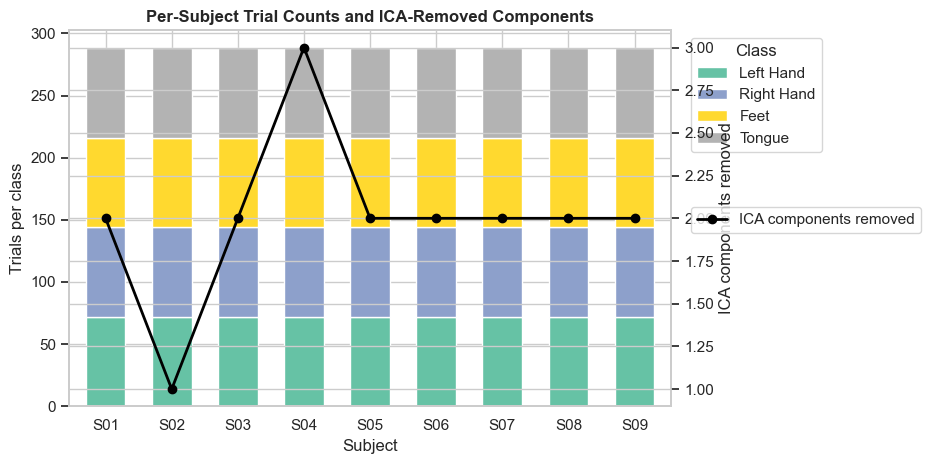

In [90]:
meta_df = pd.DataFrame(subjects_meta).sort_values('subject').reset_index(drop=True)
class_count_df = pd.DataFrame([m['class_counts'] for m in subjects_meta],
                               index=meta_df['subject']).sort_index()
class_count_df.columns = [class_names[int(c) - 1] for c in class_count_df.columns]
display(meta_df[['subject', 'n_trials', 'n_ica_excluded']])

fig, ax1 = plt.subplots(figsize=(9.5, 4.8))
class_count_df.plot(kind='bar', stacked=True, ax=ax1, colormap='Set2', width=0.6)
ax1.set_xlabel('Subject'); ax1.set_ylabel('Trials per class')
ax1.set_xticklabels([f'S{s:02d}' for s in class_count_df.index], rotation=0)
ax1.set_title('Per-Subject Trial Counts and ICA-Removed Components', fontsize=12, weight='bold')
ax1.legend(title='Class', loc='upper left', bbox_to_anchor=(1.02, 1))

ax2 = ax1.twinx()
ax2.plot(range(len(meta_df)), meta_df['n_ica_excluded'], color='black', marker='o', lw=2,
         label='ICA components removed')
ax2.set_ylabel('ICA components removed')
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 0.55))
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/subject_data_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Wavelet Packet Decomposition (WPD) Utilities

In [91]:
def compute_relevant_nodes(sfreq, n_times_probe, wavelet=WAVELET, level=WPD_LEVEL,
                            filter_band=FILTER_BAND):
    """Enumerate WPD leaf nodes (frequency order) overlapping filter_band."""
    dummy = pywt.WaveletPacket(data=np.zeros(n_times_probe), wavelet=wavelet,
                                mode='symmetric', maxlevel=level)
    all_nodes = [node.path for node in dummy.get_level(level, order='freq')]
    band_width = (sfreq / 2) / len(all_nodes)

    relevant, freq_range = [], {}
    for i, path in enumerate(all_nodes):
        lo, hi = i * band_width, (i + 1) * band_width
        freq_range[path] = (lo, hi)
        if hi > filter_band[0] and lo < filter_band[1]:
            relevant.append(path)
    return relevant, freq_range


def wpd_statistical_features(coeffs):
    """Energy, variance, and Shannon entropy of a wavelet-coefficient array."""
    energy = float(np.sum(coeffs ** 2))
    variance = float(np.var(coeffs))
    power = coeffs ** 2
    total_power = power.sum()
    if total_power > 0:
        p = power[power > 0] / total_power
        entropy = float(-np.sum(p * np.log(p)))
    else:
        entropy = 0.0
    return energy, variance, entropy


def wpd_transform(data, relevant_nodes, wavelet=WAVELET, level=WPD_LEVEL):
    """Per-epoch/channel WPD statistical features + reconstructed sub-band signals."""
    n_epochs, n_channels, n_times = data.shape
    stat_feats = np.zeros((n_epochs, n_channels, len(relevant_nodes), 3))
    subband_signals = {node: np.zeros((n_epochs, n_channels, n_times)) for node in relevant_nodes}

    for e in range(n_epochs):
        for c in range(n_channels):
            wp = pywt.WaveletPacket(data=data[e, c, :], wavelet=wavelet,
                                     mode='symmetric', maxlevel=level)
            for ni, node_path in enumerate(relevant_nodes):
                coeffs = wp[node_path].data
                stat_feats[e, c, ni, :] = wpd_statistical_features(coeffs)

                wp_rec = pywt.WaveletPacket(data=None, wavelet=wavelet,
                                             mode='symmetric', maxlevel=level)
                wp_rec[node_path] = coeffs
                reconstructed = wp_rec.reconstruct(update=False)
                subband_signals[node_path][e, c, :] = reconstructed[:n_times]
    return stat_feats, subband_signals


RELEVANT_NODES, NODE_FREQ_RANGE = compute_relevant_nodes(GLOBAL_SFREQ, GLOBAL_N_TIMES)
freq_df = pd.DataFrame([(n, *NODE_FREQ_RANGE[n]) for n in RELEVANT_NODES],
                       columns=['node', 'low_Hz', 'high_Hz'])
print(f"Selected {len(RELEVANT_NODES)} WPD sub-bands overlapping {FILTER_BAND} Hz:")
display(freq_df)

Selected 6 WPD sub-bands overlapping (8.0, 30.0) Hz:


,node,low_Hz,high_Hz
0,aaadd,7.81250,11.71875
1,aaada,11.71875,15.62500
2,aadda,15.62500,19.53125
3,aaddd,19.53125,23.43750
4,aadad,23.43750,27.34375
5,aadaa,27.34375,31.25000


## 4. Hybrid Feature Extractor — Filter-Bank CSP + WPD Statistics (leakage-safe)

In [92]:
class HybridFeatureExtractor(BaseEstimator, TransformerMixin):
    """CSP-per-WPD-subband (Filter-Bank CSP) + WPD statistical ROI features.

    CSP filters and the scaler are fit on TRAINING data only (fit()); transform()
    reuses those fitted components, so validation/test/held-out-subject data never
    leaks into feature learning.
    """
    def __init__(self, sfreq, roi_idx, n_csp_components=N_CSP_COMPONENTS,
                 wavelet=WAVELET, level=WPD_LEVEL, filter_band=FILTER_BAND, reg=CSP_REG):
        self.sfreq = sfreq
        self.roi_idx = roi_idx
        self.n_csp_components = n_csp_components
        self.wavelet = wavelet
        self.level = level
        self.filter_band = filter_band
        self.reg = reg

    def fit(self, X, y):
        self.relevant_nodes_, self.node_freq_range_ = compute_relevant_nodes(
            self.sfreq, X.shape[2], self.wavelet, self.level, self.filter_band)

        stat_feats, subband = wpd_transform(X, self.relevant_nodes_, self.wavelet, self.level)

        self.csp_models_ = {}
        csp_parts = []
        for node in self.relevant_nodes_:
            csp = CSP(n_components=self.n_csp_components, reg=self.reg, log=True, norm_trace=False)
            csp.fit(subband[node], y)
            self.csp_models_[node] = csp
            csp_parts.append(csp.transform(subband[node]))
        csp_feat = np.concatenate(csp_parts, axis=1)

        stat_roi = stat_feats[:, self.roi_idx, :, :].reshape(X.shape[0], -1)
        raw_feat = np.concatenate([csp_feat, stat_roi], axis=1)
        self.scaler_ = StandardScaler().fit(raw_feat)
        self.n_features_ = raw_feat.shape[1]
        return self

    def transform(self, X):
        stat_feats, subband = wpd_transform(X, self.relevant_nodes_, self.wavelet, self.level)
        csp_parts = [self.csp_models_[node].transform(subband[node]) for node in self.relevant_nodes_]
        csp_feat = np.concatenate(csp_parts, axis=1)
        stat_roi = stat_feats[:, self.roi_idx, :, :].reshape(X.shape[0], -1)
        raw_feat = np.concatenate([csp_feat, stat_roi], axis=1)
        return self.scaler_.transform(raw_feat)

## 5. Model — Hybrid MLP

In [93]:
class MotorImageryMLP(nn.Module):
    def __init__(self, in_features, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)  # raw logits; softmax is applied inside CrossEntropyLoss

In [94]:
def train_mlp(X_train, y_train, X_val, y_val, in_features, n_classes=4,
              n_epochs=N_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
              lr=LR, weight_decay=WEIGHT_DECAY, seed=RANDOM_STATE, device=DEVICE, verbose=False):
    """Train MotorImageryMLP with early stopping on validation loss."""
    torch.manual_seed(seed)
    model = MotorImageryMLP(in_features, n_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

    loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size,
                         shuffle=True, generator=torch.Generator().manual_seed(seed))

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss, best_state, patience_counter = float('inf'), None, 0

    for epoch in range(n_epochs):
        model.train()
        running_loss, correct, seen = 0.0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            seen += xb.size(0)
        train_loss, train_acc = running_loss / seen, correct / seen

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            val_acc = (val_logits.argmax(dim=1) == y_val_t).float().mean().item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        if verbose and (epoch % 20 == 0):
            print(f"  epoch {epoch:03d} | train_loss={train_loss:.3f} val_loss={val_loss:.3f} "
                  f"val_acc={val_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

## 6. Evaluation Utilities

In [95]:
def compute_metrics(y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=range(1, len(class_names) + 1))
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred, labels=range(1, len(class_names) + 1))
    return {
        'accuracy': acc, 'macro_precision': macro_p, 'macro_recall': macro_r, 'macro_f1': macro_f1,
        'per_class_precision': dict(zip(class_names, precision)),
        'per_class_recall': dict(zip(class_names, recall)),
        'per_class_f1': dict(zip(class_names, f1)),
        'support': dict(zip(class_names, support)),
        'confusion_matrix': cm,
    }

## 7. Leave-One-Subject-Out Cross-Validation

In [96]:
def make_loso_split(subjects_data, test_subject, val_fraction=VAL_FRACTION, seed=RANDOM_STATE):
    """Pool all subjects except test_subject for training; carve a stratified
    validation slice out of that pool for early stopping. test_subject is never
    touched until final evaluation."""
    train_subjects = [s for s in subjects_data if s != test_subject]
    X_pool = np.concatenate([subjects_data[s][0] for s in train_subjects], axis=0)
    y_pool = np.concatenate([subjects_data[s][1] for s in train_subjects], axis=0)

    idx_tr, idx_val = train_test_split(np.arange(len(y_pool)), test_size=val_fraction,
                                        stratify=y_pool, random_state=seed)
    X_test, y_test = subjects_data[test_subject]
    return X_pool[idx_tr], y_pool[idx_tr], X_pool[idx_val], y_pool[idx_val], X_test, y_test, train_subjects

In [97]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

fold_results = {}
SUBJECT_IDS = sorted(subjects_data.keys())

for test_subject in SUBJECT_IDS:
    t0 = time.time()
    X_train, y_train, X_val, y_val, X_test, y_test, train_subjects = make_loso_split(
        subjects_data, test_subject
    )

    hfe = HybridFeatureExtractor(
        sfreq=GLOBAL_SFREQ,
        roi_idx=roi_idx,
        n_csp_components=N_CSP_COMPONENTS
    )
    hfe.fit(X_train, y_train)
    X_train_f = hfe.transform(X_train)
    X_val_f = hfe.transform(X_val)
    X_test_f = hfe.transform(X_test)

    baseline_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    baseline_clf.fit(X_train_f, y_train)
    baseline_acc = baseline_clf.score(X_test_f, y_test)

    model, history = train_mlp(
        X_train_f,
        y_train - 1,
        X_val_f,
        y_val - 1,
        in_features=X_train_f.shape[1],
        n_classes=len(class_names)
    )

    model.eval()
    with torch.no_grad():
        logits = model(
            torch.tensor(X_test_f, dtype=torch.float32).to(DEVICE)
        )
        y_pred = logits.argmax(dim=1).cpu().numpy() + 1

    metrics = compute_metrics(y_test, y_pred, class_names)

    fold_results[test_subject] = {
        'metrics': metrics,
        'history': history,
        'y_true': y_test,
        'y_pred': y_pred,
        'baseline_accuracy': baseline_acc,
        'feature_extractor': hfe,
        'model_state': model.state_dict(),
        'train_subjects': train_subjects,
        'n_features': X_train_f.shape[1],
    }

    print(
        f"[Fold test=S{test_subject:02d}] "
        f"MLP acc={metrics['accuracy']:.3f} | "
        f"baseline acc={baseline_acc:.3f} | "
        f"macro-F1={metrics['macro_f1']:.3f} | "
        f"{time.time() - t0:.1f}s"
    )

for s, res in fold_results.items():
    torch.save(
        res['model_state'],
        os.path.join(MODELS_DIR, f'mlp_test_subject_{s:02d}.pt')
    )
    joblib.dump(
        res['feature_extractor'],
        os.path.join(MODELS_DIR, f'feature_extractor_test_subject_{s:02d}.joblib')
    )

[Fold test=S01] MLP acc=0.566 | baseline acc=0.503 | macro-F1=0.511 | 43.1s
[Fold test=S02] MLP acc=0.247 | baseline acc=0.285 | macro-F1=0.157 | 41.0s
[Fold test=S03] MLP acc=0.524 | baseline acc=0.493 | macro-F1=0.504 | 41.3s
[Fold test=S04] MLP acc=0.347 | baseline acc=0.306 | macro-F1=0.294 | 42.1s
[Fold test=S05] MLP acc=0.295 | baseline acc=0.285 | macro-F1=0.229 | 41.9s
[Fold test=S06] MLP acc=0.285 | baseline acc=0.333 | macro-F1=0.183 | 42.7s
[Fold test=S07] MLP acc=0.351 | baseline acc=0.285 | macro-F1=0.298 | 41.8s
[Fold test=S08] MLP acc=0.569 | baseline acc=0.524 | macro-F1=0.568 | 41.3s
[Fold test=S09] MLP acc=0.424 | baseline acc=0.420 | macro-F1=0.379 | 43.0s


### 7.1 Aggregate LOSO results

In [98]:
rows = []
for s, res in fold_results.items():
    m = res['metrics']
    row = {
        'subject': s, 'n_test_trials': int(sum(m['support'].values())),
        'mlp_accuracy': m['accuracy'], 'baseline_accuracy': res['baseline_accuracy'],
        'macro_precision': m['macro_precision'], 'macro_recall': m['macro_recall'],
        'macro_f1': m['macro_f1'],
    }
    for cname in class_names:
        row[f'f1_{cname}'] = m['per_class_f1'][cname]
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values('subject').reset_index(drop=True)
results_df.to_csv(os.path.join(RESULTS_DIR, 'loso_results.csv'), index=False)
display(results_df.round(3))

print(f"\nMean MLP accuracy:      {results_df['mlp_accuracy'].mean():.3f} +/- {results_df['mlp_accuracy'].std():.3f}")
print(f"Mean baseline accuracy: {results_df['baseline_accuracy'].mean():.3f} +/- {results_df['baseline_accuracy'].std():.3f}")
print(f"Mean macro-F1:          {results_df['macro_f1'].mean():.3f} +/- {results_df['macro_f1'].std():.3f}")
print(f"Chance level ({len(class_names)} balanced classes): {1 / len(class_names):.3f}")

,subject,n_test_trials,mlp_accuracy,baseline_accuracy,macro_precision,macro_recall,macro_f1,f1_Left Hand,f1_Right Hand,f1_Feet,f1_Tongue
0,1,288,0.566,0.503,0.635,0.566,0.511,0.634,0.680,0.581,0.150
1,2,288,0.247,0.285,0.367,0.247,0.157,0.000,0.218,0.382,0.027
2,3,288,0.524,0.493,0.682,0.524,0.504,0.576,0.442,0.465,0.532
3,4,288,0.347,0.306,0.350,0.347,0.294,0.286,0.419,0.026,0.443
4,5,288,0.295,0.285,0.268,0.295,0.229,0.345,0.388,0.182,0.000
5,6,288,0.285,0.333,0.297,0.285,0.183,0.053,0.000,0.225,0.453
6,7,288,0.351,0.285,0.270,0.351,0.298,0.438,0.454,0.301,0.000
7,8,288,0.569,0.524,0.613,0.569,0.568,0.528,0.639,0.548,0.556
8,9,288,0.424,0.420,0.515,0.424,0.379,0.482,0.396,0.140,0.500



Mean MLP accuracy:      0.401 +/- 0.125
Mean baseline accuracy: 0.382 +/- 0.103
Mean macro-F1:          0.347 +/- 0.152
Chance level (4 balanced classes): 0.250


## 8. Cross-Subject Comparisons & Visualizations

### 8.1 Test accuracy by held-out subject (Hybrid MLP vs. CSP+LogReg baseline)

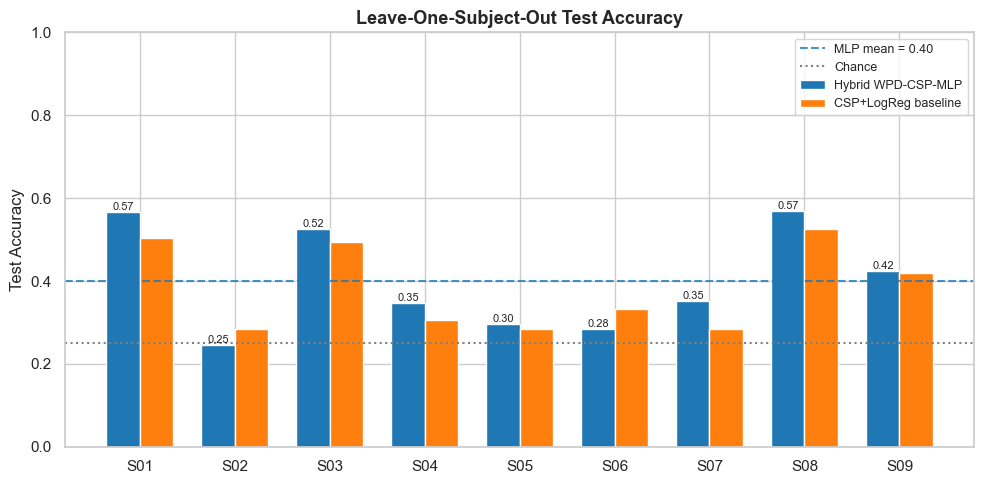

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x - width / 2, results_df['mlp_accuracy'], width, label='Hybrid WPD-CSP-MLP', color='#1f77b4')
ax.bar(x + width / 2, results_df['baseline_accuracy'], width, label='CSP+LogReg baseline', color='#ff7f0e')
ax.axhline(results_df['mlp_accuracy'].mean(), color='#1f77b4', ls='--', lw=1.5, alpha=0.8,
           label=f"MLP mean = {results_df['mlp_accuracy'].mean():.2f}")
ax.axhline(1 / len(class_names), color='grey', ls=':', lw=1.5, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels([f'S{s:02d}' for s in results_df['subject']])
ax.set_ylabel('Test Accuracy'); ax.set_ylim(0, 1.0)
ax.set_title('Leave-One-Subject-Out Test Accuracy', fontsize=13, weight='bold')
for b in bars1:
    ax.annotate(f'{b.get_height():.2f}', (b.get_x() + b.get_width() / 2, b.get_height()),
                ha='center', va='bottom', fontsize=8)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/loso_accuracy_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Per-class F1-score spread across subjects

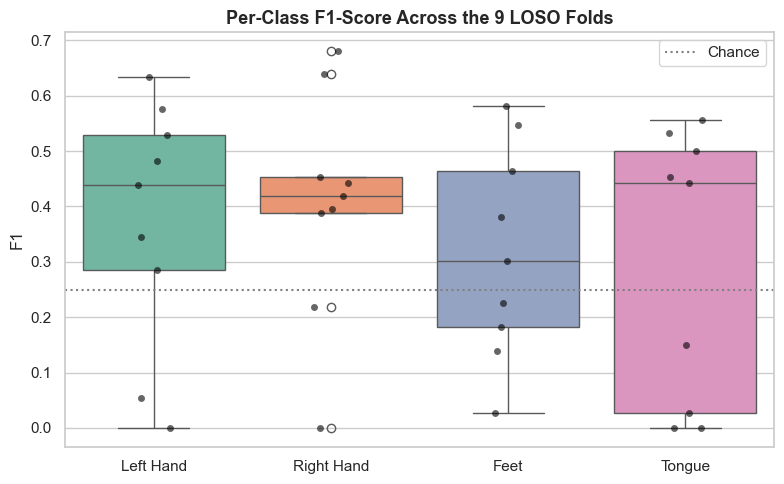

In [100]:
f1_cols = [f'f1_{c}' for c in class_names]
melted = results_df.melt(id_vars='subject', value_vars=f1_cols, var_name='class', value_name='F1')
melted['class'] = melted['class'].str.replace('f1_', '', regex=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=melted, x='class', y='F1', hue='class', palette='Set2', ax=ax, legend=False)
sns.stripplot(data=melted, x='class', y='F1', color='black', alpha=0.6, jitter=True, ax=ax)
ax.axhline(1 / len(class_names), color='grey', ls=':', label='Chance')
ax.set_title('Per-Class F1-Score Across the 9 LOSO Folds', fontsize=13, weight='bold')
ax.set_xlabel(''); ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/per_class_f1_across_subjects.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Per-subject and pooled confusion matrices

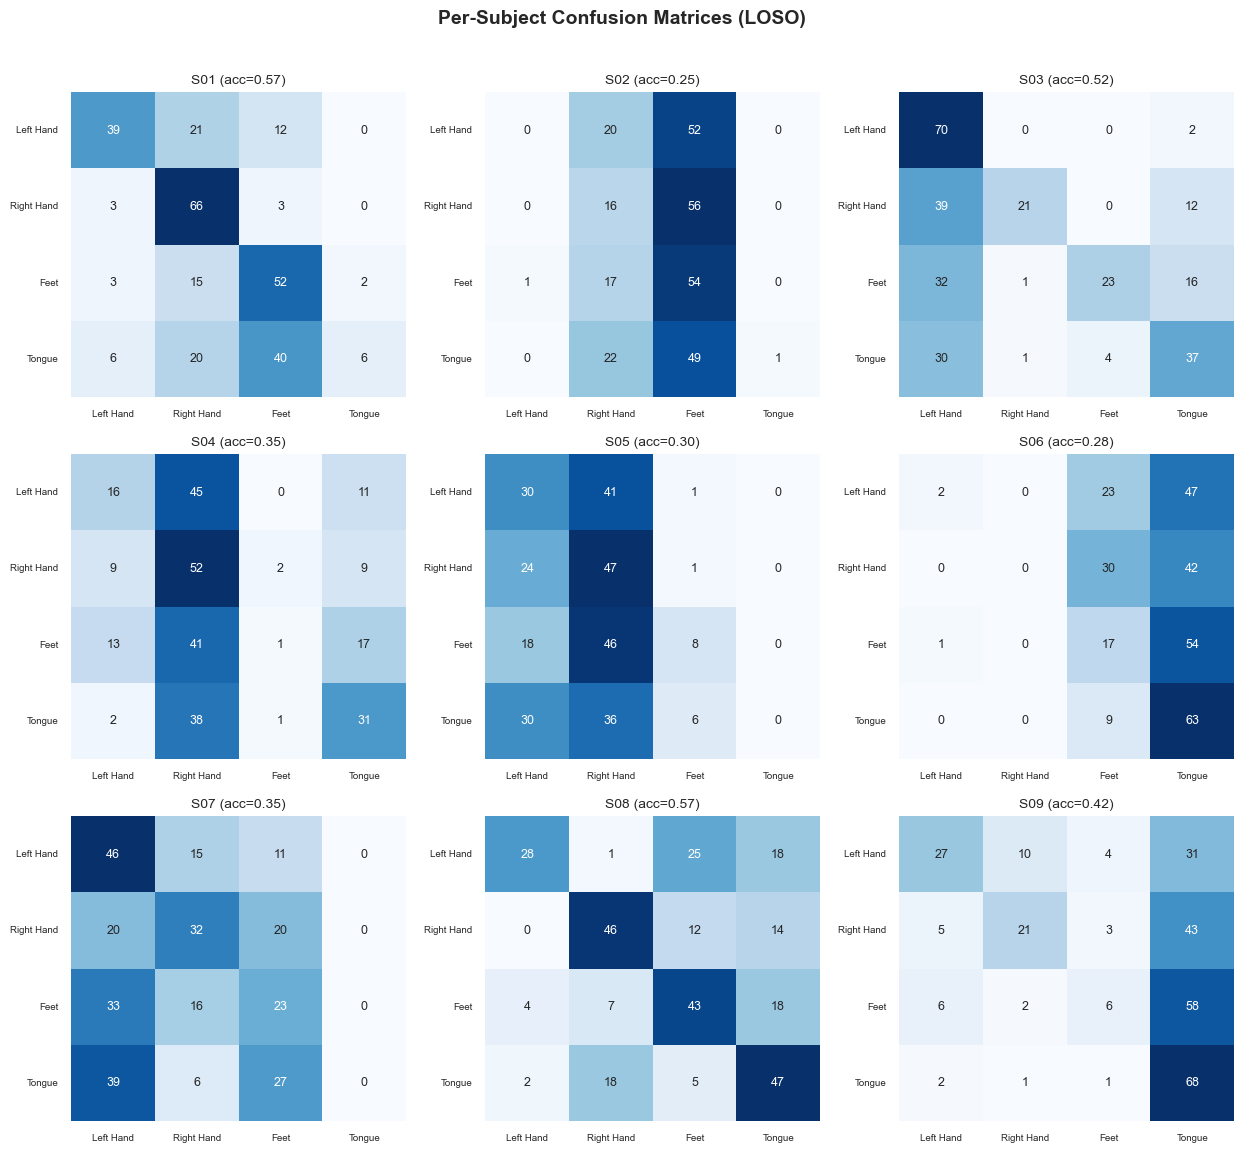

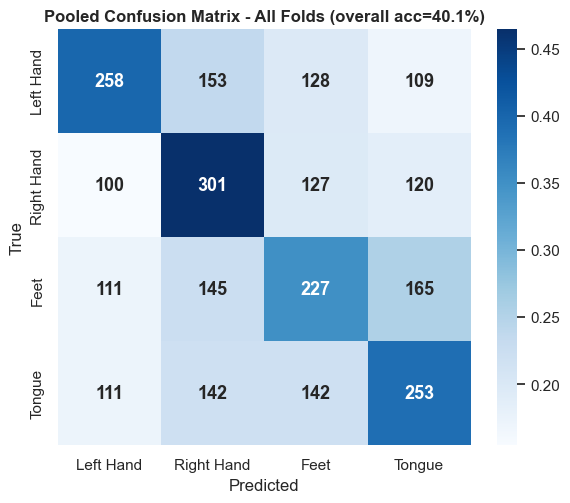

In [101]:
n_subj = len(fold_results)
ncols = 3
nrows = int(np.ceil(n_subj / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
axes = np.array(axes).reshape(-1)
for i, s in enumerate(sorted(fold_results)):
    cm = fold_results[s]['metrics']['confusion_matrix']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, annot_kws={'size': 9})
    axes[i].set_title(f"S{s:02d} (acc={fold_results[s]['metrics']['accuracy']:.2f})", fontsize=10)
    axes[i].tick_params(labelsize=7)
for j in range(n_subj, len(axes)):
    axes[j].axis('off')
plt.suptitle('Per-Subject Confusion Matrices (LOSO)', fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/confusion_matrix_grid.png', dpi=150, bbox_inches='tight')
plt.show()

all_true = np.concatenate([fold_results[s]['y_true'] for s in fold_results])
all_pred = np.concatenate([fold_results[s]['y_pred'] for s in fold_results])
cm_all = confusion_matrix(all_true, all_pred, labels=range(1, len(class_names) + 1))
cm_all_norm = cm_all.astype(float) / cm_all.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5.2))
sns.heatmap(cm_all_norm, annot=cm_all, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=class_names, yticklabels=class_names, annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title(f'Pooled Confusion Matrix - All Folds (overall acc={accuracy_score(all_true, all_pred):.1%})',
             fontsize=12, weight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/confusion_matrix_pooled.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Training stability across folds

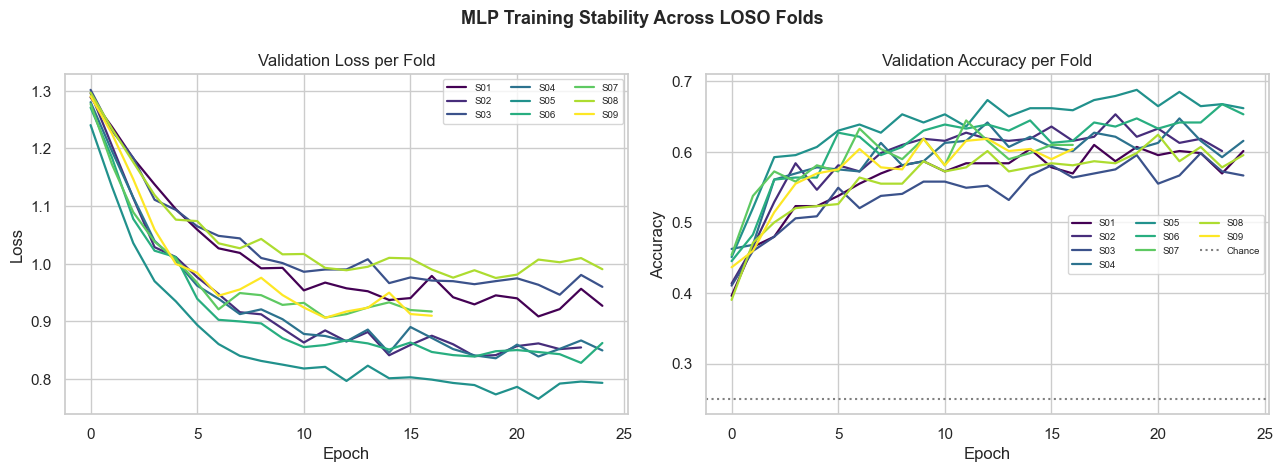

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = plt.cm.viridis(np.linspace(0, 1, len(fold_results)))
for color, s in zip(colors, sorted(fold_results)):
    h = fold_results[s]['history']
    axes[0].plot(h['val_loss'], color=color, lw=1.6, label=f'S{s:02d}')
    axes[1].plot(h['val_acc'], color=color, lw=1.6, label=f'S{s:02d}')
axes[0].set_title('Validation Loss per Fold'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('Validation Accuracy per Fold'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].axhline(1 / len(class_names), color='grey', ls=':', label='Chance')
axes[0].legend(fontsize=7, ncol=3); axes[1].legend(fontsize=7, ncol=3)
plt.suptitle('MLP Training Stability Across LOSO Folds', fontsize=13, weight='bold')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/training_curves_all_folds.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.5 CSP spatial patterns across subjects

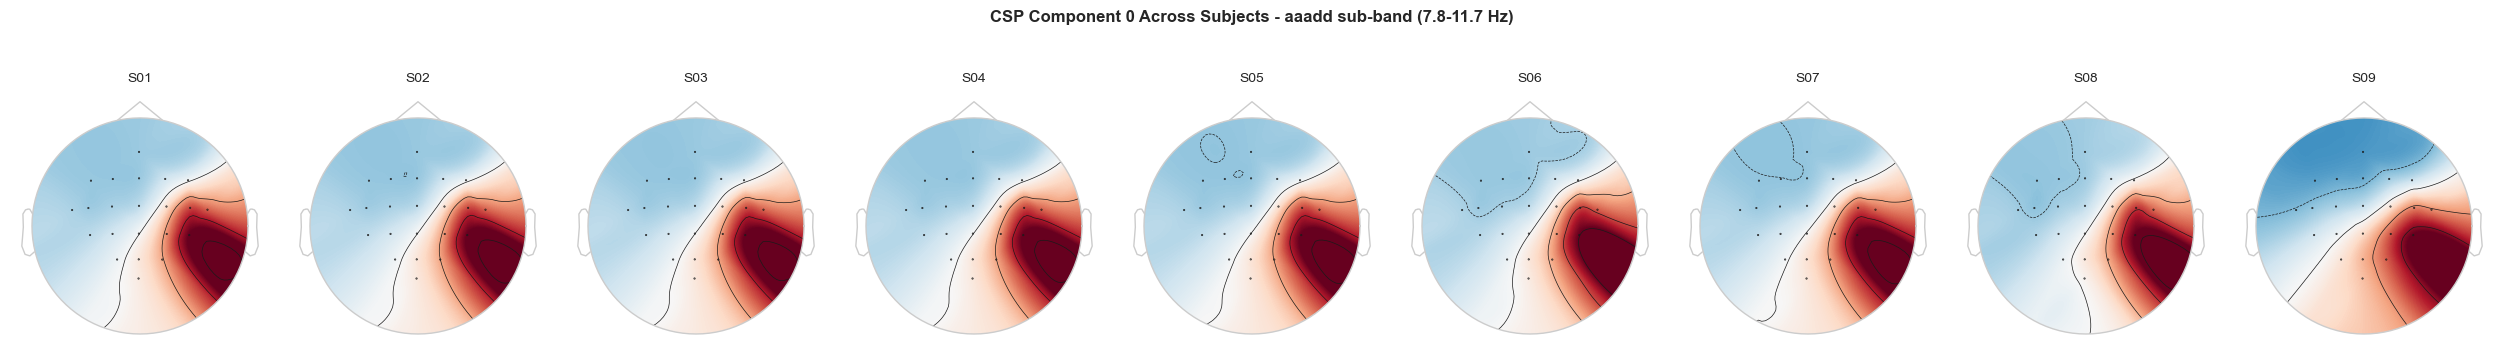

In [103]:
rep_node = RELEVANT_NODES[0]
lo, hi = NODE_FREQ_RANGE[rep_node]
info_plot = mne.create_info(ch_names_ref, sfreq=GLOBAL_SFREQ, ch_types='eeg')
info_plot.set_montage(mne.channels.make_standard_montage('standard_1020'), on_missing='ignore')

subj_list = sorted(fold_results)
fig, axes = plt.subplots(1, len(subj_list), figsize=(2.8 * len(subj_list), 3.2))
axes = np.atleast_1d(axes)
for ax, s in zip(axes, subj_list):
    pattern = fold_results[s]['feature_extractor'].csp_models_[rep_node].patterns_[0]
    mne.viz.plot_topomap(pattern, info_plot, axes=ax, show=False, cmap='RdBu_r', sensors=True, contours=4)
    ax.set_title(f'S{s:02d}', fontsize=10)
plt.suptitle(f'CSP Component 0 Across Subjects - {rep_node} sub-band ({lo:.1f}-{hi:.1f} Hz)',
             fontsize=12, weight='bold', y=1.08)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/csp_topomap_across_subjects.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.6 WPD energy feature distribution across subjects

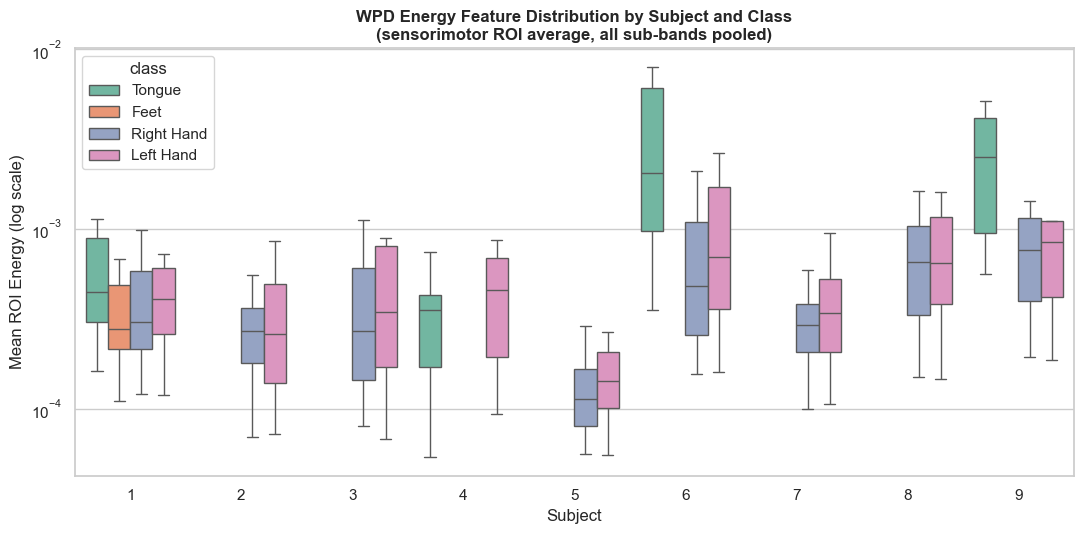

In [104]:
energy_records = []
for s, (data, labels) in subjects_data.items():
    stat_feats, _ = wpd_transform(data, RELEVANT_NODES)
    roi_energy = stat_feats[:, roi_idx, :, 0].mean(axis=1)  # mean ROI energy per sub-band
    for ei, node in enumerate(RELEVANT_NODES):
        for e_val, lab in zip(roi_energy[:, ei], labels):
            energy_records.append({'subject': s, 'sub_band': node,
                                    'class': class_names[lab - 1], 'energy': e_val})
energy_df = pd.DataFrame(energy_records)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=energy_df, x='subject', y='energy', hue='class', palette='Set2',
            showfliers=False, ax=ax)
ax.set_yscale('log')
ax.set_title('WPD Energy Feature Distribution by Subject and Class\n(sensorimotor ROI average, all sub-bands pooled)',
             fontsize=12, weight='bold')
ax.set_xlabel('Subject'); ax.set_ylabel('Mean ROI Energy (log scale)')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/wpd_energy_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.7 Cross-subject transfer heatmap (optional, CSP+LogReg)

Pairwise transfer from S01 done.
Pairwise transfer from S02 done.
Pairwise transfer from S03 done.
Pairwise transfer from S04 done.
Pairwise transfer from S05 done.
Pairwise transfer from S06 done.
Pairwise transfer from S07 done.
Pairwise transfer from S08 done.
Pairwise transfer from S09 done.


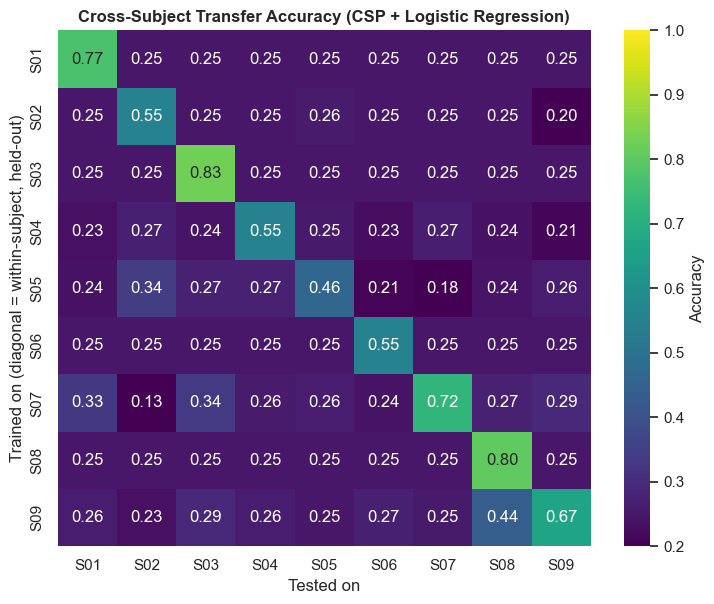

Mean within-subject accuracy (diagonal):    0.656
Mean cross-subject accuracy (off-diagonal): 0.254


In [105]:
if RUN_PAIRWISE_TRANSFER:
    subj_ids = sorted(subjects_data.keys())
    transfer_acc = np.zeros((len(subj_ids), len(subj_ids)))

    for i, s_train in enumerate(subj_ids):
        X_s, y_s = subjects_data[s_train]

        # Diagonal: proper held-out within-subject accuracy (70/30 split of the SAME subject).
        idx_tr, idx_te = train_test_split(np.arange(len(y_s)), test_size=0.3,
                                           stratify=y_s, random_state=RANDOM_STATE)
        hfe_within = HybridFeatureExtractor(sfreq=GLOBAL_SFREQ, roi_idx=roi_idx,
                                             n_csp_components=N_CSP_COMPONENTS)
        hfe_within.fit(X_s[idx_tr], y_s[idx_tr])
        clf_within = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(
            hfe_within.transform(X_s[idx_tr]), y_s[idx_tr])
        transfer_acc[i, i] = clf_within.score(hfe_within.transform(X_s[idx_te]), y_s[idx_te])

        # Off-diagonal: fit on ALL of subject i, test on ALL of subject j (fully independent).
        hfe_full = HybridFeatureExtractor(sfreq=GLOBAL_SFREQ, roi_idx=roi_idx,
                                           n_csp_components=N_CSP_COMPONENTS)
        hfe_full.fit(X_s, y_s)
        clf_full = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(
            hfe_full.transform(X_s), y_s)
        for j, s_test in enumerate(subj_ids):
            if j == i:
                continue
            X_t, y_t = subjects_data[s_test]
            transfer_acc[i, j] = clf_full.score(hfe_full.transform(X_t), y_t)
        print(f"Pairwise transfer from S{s_train:02d} done.")

    transfer_df = pd.DataFrame(transfer_acc, index=[f'S{s:02d}' for s in subj_ids],
                                columns=[f'S{s:02d}' for s in subj_ids])
    transfer_df.to_csv(os.path.join(RESULTS_DIR, 'pairwise_transfer_accuracy.csv'))

    fig, ax = plt.subplots(figsize=(7.5, 6.2))
    sns.heatmap(transfer_df, annot=True, fmt='.2f', cmap='viridis', vmin=0.2, vmax=1.0,
                cbar_kws={'label': 'Accuracy'}, ax=ax)
    ax.set_xlabel('Tested on'); ax.set_ylabel('Trained on (diagonal = within-subject, held-out)')
    ax.set_title('Cross-Subject Transfer Accuracy (CSP + Logistic Regression)', fontsize=12, weight='bold')
    plt.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/pairwise_transfer_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    diag_mean = np.diag(transfer_acc).mean()
    off_diag_mean = transfer_acc[~np.eye(len(subj_ids), dtype=bool)].mean()
    print(f"Mean within-subject accuracy (diagonal):    {diag_mean:.3f}")
    print(f"Mean cross-subject accuracy (off-diagonal): {off_diag_mean:.3f}")

## 9. Summary

In [107]:
print("=" * 60)
print("LOSO SUMMARY")
print("=" * 60)
print(f"Subjects evaluated: {len(results_df)}")
print(f"Hybrid MLP  - mean acc: {results_df['mlp_accuracy'].mean():.3f} +/- {results_df['mlp_accuracy'].std():.3f}")
print(f"Baseline LR - mean acc: {results_df['baseline_accuracy'].mean():.3f} +/- {results_df['baseline_accuracy'].std():.3f}")
print(f"Macro-F1    - mean:     {results_df['macro_f1'].mean():.3f} +/- {results_df['macro_f1'].std():.3f}")
print(f"Chance level: {1 / len(class_names):.3f}")

best_i = results_df['mlp_accuracy'].idxmax()
worst_i = results_df['mlp_accuracy'].idxmin()
print(f"\nBest subject:    S{int(results_df.loc[best_i, 'subject']):02d} "
      f"({results_df.loc[best_i, 'mlp_accuracy']:.3f})")
print(f"Hardest subject: S{int(results_df.loc[worst_i, 'subject']):02d} "
      f"({results_df.loc[worst_i, 'mlp_accuracy']:.3f})")


LOSO SUMMARY
Subjects evaluated: 9
Hybrid MLP  - mean acc: 0.401 +/- 0.125
Baseline LR - mean acc: 0.382 +/- 0.103
Macro-F1    - mean:     0.347 +/- 0.152
Chance level: 0.250

Best subject:    S08 (0.569)
Hardest subject: S02 (0.247)


/var/folders/pm/pw42yk0s04qfkht48phb737c0000gn/T/ipykernel_16239/545959963.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.965])


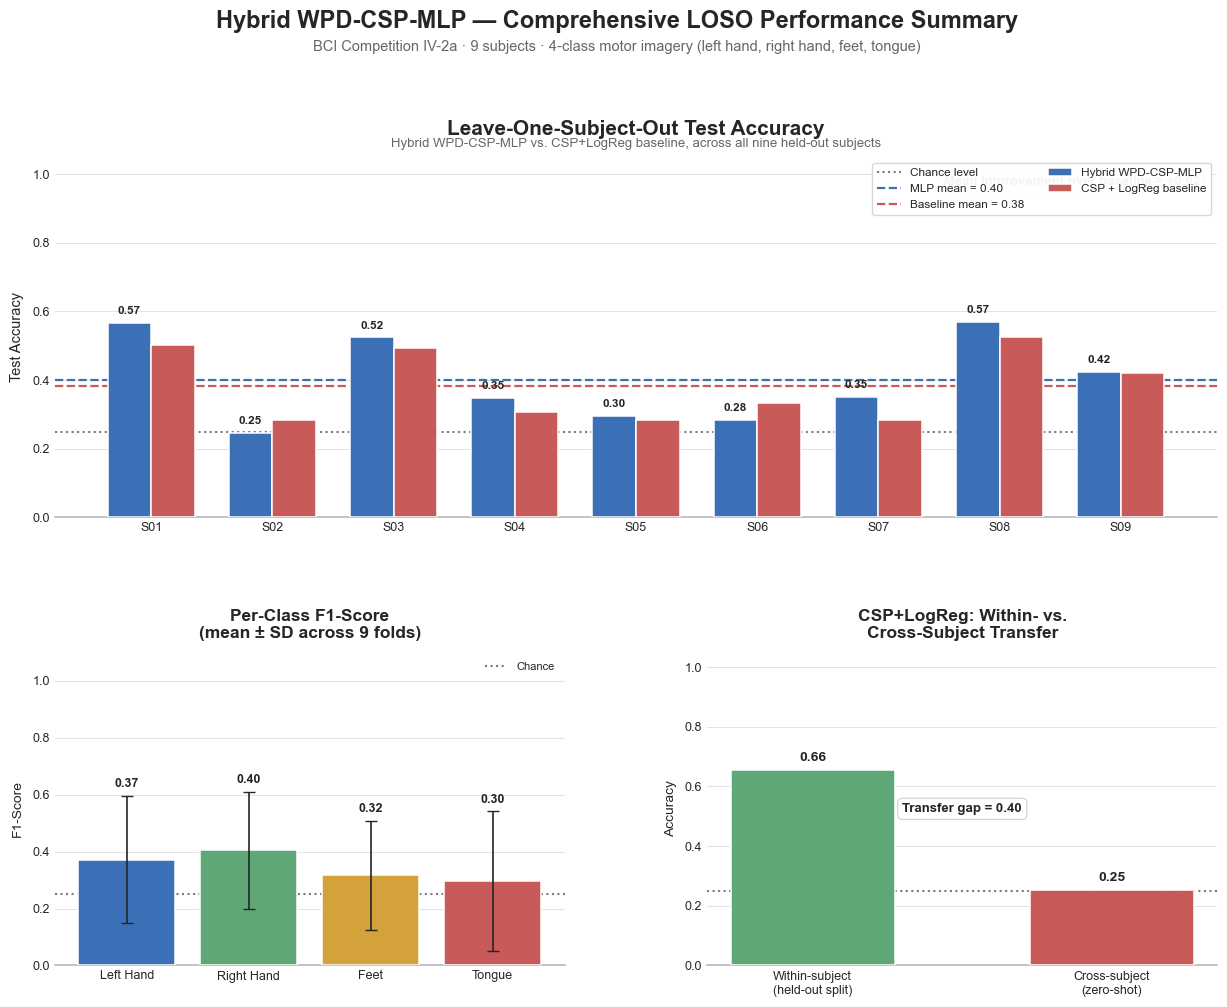

In [111]:
import matplotlib.gridspec as gridspec

# ---- Derived summary statistics ----
mlp_mean = results_df['mlp_accuracy'].mean()
mlp_std = results_df['mlp_accuracy'].std()
baseline_mean = results_df['baseline_accuracy'].mean()
baseline_std = results_df['baseline_accuracy'].std()
macro_f1_mean = results_df['macro_f1'].mean()
chance_level = 1 / len(class_names)
mlp_over_baseline = mlp_mean - baseline_mean

best_i = results_df['mlp_accuracy'].idxmax()
worst_i = results_df['mlp_accuracy'].idxmin()
best_subj = int(results_df.loc[best_i, 'subject'])
worst_subj = int(results_df.loc[worst_i, 'subject'])
best_acc = results_df.loc[best_i, 'mlp_accuracy']
worst_acc = results_df.loc[worst_i, 'mlp_accuracy']

has_transfer = ('transfer_df' in globals()) and RUN_PAIRWISE_TRANSFER
if has_transfer:
    transfer_arr = transfer_df.values
    within_mean = np.diag(transfer_arr).mean()
    across_mean = transfer_arr[~np.eye(len(transfer_arr), dtype=bool)].mean()

# ---- Shared palette (consistent across every panel) ----
mlp_color = '#3B6FB6'
baseline_color = '#C85A5A'
chance_color = '#7A7A7A'
accent_color = '#5FA777'
text_color = '#252525'
grid_color = '#E2E2E2'
spine_color = '#BDBDBD'


def _style_axis(ax):
    """Apply the shared clean-axis styling used across all panels."""
    ax.grid(axis='y', linestyle='-', linewidth=0.7, color=grid_color, zorder=0)
    ax.grid(axis='x', visible=False)
    for spine in ('top', 'right', 'left'):
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color(spine_color)
    ax.tick_params(axis='x', length=0, labelsize=9)
    ax.tick_params(axis='y', length=0, labelsize=9)


fig = plt.figure(figsize=(15, 10.5))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.15, 1], hspace=0.4, wspace=0.28)

# ============================================================
# Panel A (top, full width): MLP vs. baseline accuracy by subject
# ============================================================
ax0 = fig.add_subplot(gs[0, :])

subjects_lbl = [f'S{s:02d}' for s in results_df['subject']]
x = np.arange(len(results_df))
width = 0.36

bars_mlp = ax0.bar(
    x - width / 2, results_df['mlp_accuracy'], width,
    label='Hybrid WPD-CSP-MLP', color=mlp_color,
    edgecolor='white', linewidth=1.1, zorder=3
)
bars_base = ax0.bar(
    x + width / 2, results_df['baseline_accuracy'], width,
    label='CSP + LogReg baseline', color=baseline_color,
    edgecolor='white', linewidth=1.1, zorder=3
)

ax0.axhline(chance_level, color=chance_color, linestyle=':', linewidth=1.5,
            label='Chance level', zorder=2)
ax0.axhline(mlp_mean, color=mlp_color, linestyle='--', linewidth=1.6,
            label=f'MLP mean = {mlp_mean:.2f}', zorder=2)
ax0.axhline(baseline_mean, color=baseline_color, linestyle='--', linewidth=1.6,
            label=f'Baseline mean = {baseline_mean:.2f}', zorder=2)

for bar, value in zip(bars_mlp, results_df['mlp_accuracy']):
    ax0.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.2f}',
              ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=text_color)

ax0.annotate(
    f'Mean improvement over baseline = +{mlp_over_baseline:.2f}',
    xy=(0.985, 0.93), xycoords='axes fraction',
    ha='right', va='center', fontsize=9.5, fontweight='bold', color=text_color,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D0D0D0', linewidth=0.8)
)

ax0.set_title('Leave-One-Subject-Out Test Accuracy', fontsize=15, fontweight='bold', pad=16)
ax0.text(
    0.5, 1.02,
    'Hybrid WPD-CSP-MLP vs. CSP+LogReg baseline, across all nine held-out subjects',
    transform=ax0.transAxes, ha='center', va='bottom', fontsize=9.5, color='#666666'
)
ax0.set_xticks(x)
ax0.set_xticklabels(subjects_lbl, fontsize=9.5)
ax0.set_ylabel('Test Accuracy', fontsize=10.5, labelpad=6)
ax0.set_ylim(0, 1.05)
_style_axis(ax0)
ax0.legend(loc='upper right', fontsize=8.5, frameon=True, fancybox=True,
           framealpha=0.95, edgecolor='#D5D5D5', ncol=2)

# ============================================================
# Panel B (bottom-left): per-class F1-score across LOSO folds
# ============================================================
ax1 = fig.add_subplot(gs[1, 0])

f1_cols = [f'f1_{c}' for c in class_names]
f1_means = results_df[f1_cols].mean().values
f1_stds = results_df[f1_cols].std().values
class_colors = ['#3B6FB6', '#5FA777', '#D3A23A', '#C85A5A'][:len(class_names)]

bars_f1 = ax1.bar(
    class_names, f1_means, yerr=f1_stds,
    color=class_colors, edgecolor='white', linewidth=1.1,
    capsize=4, error_kw=dict(elinewidth=1.2, ecolor=text_color), zorder=3
)

ax1.axhline(chance_level, color=chance_color, linestyle=':', linewidth=1.5,
            label='Chance', zorder=2)

for bar, mean_val, std_val in zip(bars_f1, f1_means, f1_stds):
    ax1.text(bar.get_x() + bar.get_width() / 2, mean_val + std_val + 0.02, f'{mean_val:.2f}',
              ha='center', va='bottom', fontsize=9, fontweight='bold', color=text_color)

ax1.set_title('Per-Class F1-Score\n(mean ± SD across 9 folds)', fontsize=12.5, fontweight='bold', pad=10)
ax1.set_ylabel('F1-Score', fontsize=10, labelpad=6)
ax1.set_ylim(0, 1.1)
_style_axis(ax1)
ax1.legend(loc='upper right', fontsize=8, frameon=False)

# ============================================================
# Panel C (bottom-right): cross-subject transfer, or a headline
# scorecard if the pairwise-transfer heatmap wasn't computed
# ============================================================
ax2 = fig.add_subplot(gs[1, 1])

if has_transfer:
    transfer_labels = ['Within-subject\n(held-out split)', 'Cross-subject\n(zero-shot)']
    transfer_values = [within_mean, across_mean]
    transfer_colors = [accent_color, baseline_color]

    bars_t = ax2.bar(transfer_labels, transfer_values, color=transfer_colors,
                      edgecolor='white', linewidth=1.1, width=0.55, zorder=3)
    ax2.axhline(chance_level, color=chance_color, linestyle=':', linewidth=1.5,
                label='Chance', zorder=2)

    for bar, value in zip(bars_t, transfer_values):
        ax2.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.2f}',
                  ha='center', va='bottom', fontsize=10, fontweight='bold', color=text_color)

    transfer_gap = within_mean - across_mean
    ax2.annotate(
        f'Transfer gap = {transfer_gap:.2f}',
        xy=(0.5, 0.5), xycoords='axes fraction',
        ha='center', va='center', fontsize=9.5, fontweight='bold', color=text_color,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D0D0D0', linewidth=0.8)
    )

    ax2.set_title('CSP+LogReg: Within- vs.\nCross-Subject Transfer', fontsize=12.5, fontweight='bold', pad=10)
    ax2.set_ylabel('Accuracy', fontsize=10, labelpad=6)
    ax2.set_ylim(0, 1.05)
    _style_axis(ax2)
else:
    ax2.axis('off')
    scorecard = (
        f"Subjects evaluated:  {len(results_df)}\n\n"
        f"Hybrid MLP accuracy:  {mlp_mean:.3f} +/- {mlp_std:.3f}\n"
        f"Baseline accuracy:    {baseline_mean:.3f} +/- {baseline_std:.3f}\n"
        f"Macro-F1 (MLP):       {macro_f1_mean:.3f}\n"
        f"Chance level:         {chance_level:.3f}\n\n"
        f"Best subject:     S{best_subj:02d}  ({best_acc:.3f})\n"
        f"Hardest subject:  S{worst_subj:02d}  ({worst_acc:.3f})"
    )
    ax2.text(0.06, 0.92, 'Headline Numbers', fontsize=13, fontweight='bold',
              color=text_color, transform=ax2.transAxes, va='top')
    ax2.text(0.06, 0.78, scorecard, fontsize=11, color=text_color,
              transform=ax2.transAxes, va='top', family='monospace', linespacing=1.9)
    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_color('#D5D5D5')

# ============================================================
# Overall figure title
# ============================================================
fig.suptitle('Hybrid WPD-CSP-MLP — Comprehensive LOSO Performance Summary',
             fontsize=17, fontweight='bold', y=1.02)
fig.text(
    0.5, 0.978,
    'BCI Competition IV-2a · 9 subjects · 4-class motor imagery (left hand, right hand, feet, tongue)',
    ha='center', va='bottom', fontsize=10.5, color='#666666'
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

fig.savefig(
    f'{FIGURES_DIR}/comprehensive_summary_dashboard.png',
    dpi=400, bbox_inches='tight', facecolor='white'
)

plt.show()


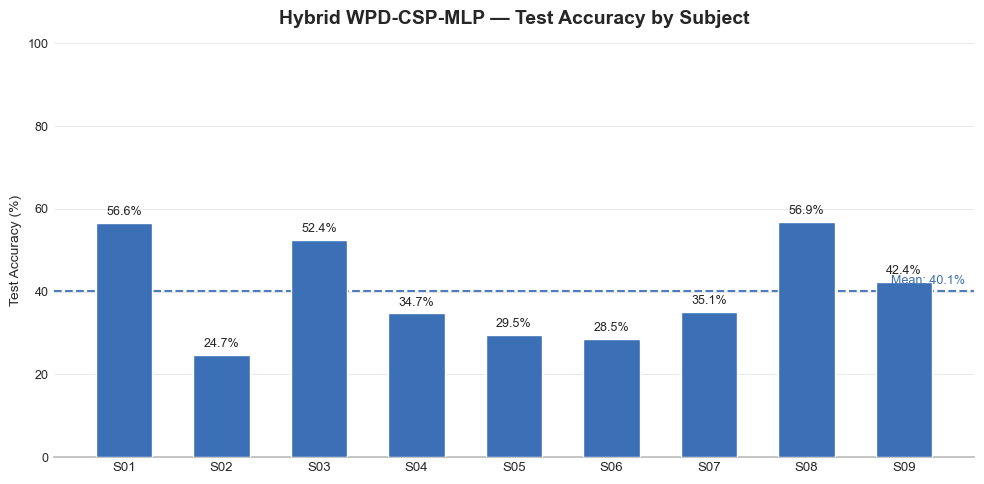

In [ ]:
mlp_pct = results_df['mlp_accuracy'] * 100
mlp_mean_pct = mlp_pct.mean()

fig, ax = plt.subplots(figsize=(10, 5))

subjects_lbl = [f'S{s:02d}' for s in results_df['subject']]
x = np.arange(len(results_df))

bars = ax.bar(
    x,
    mlp_pct,
    width=0.58,
    color='#3B6FB6',
    edgecolor='white',
    linewidth=1,
    zorder=3
)

ax.axhline(
    mlp_mean_pct,
    color='#3B6FB6',
    linestyle='--',
    linewidth=1.5,
    alpha=0.9,
    zorder=2
)

for bar, value in zip(bars, mlp_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.2,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#252525'
    )

ax.text(
    0.99,
    mlp_mean_pct + 1,
    f'Mean: {mlp_mean_pct:.1f}%',
    transform=ax.get_yaxis_transform(),
    ha='right',
    va='bottom',
    fontsize=9,
    color='#3B6FB6'
)

ax.set_title(
    'Hybrid WPD-CSP-MLP — Test Accuracy by Subject',
    fontsize=14,
    fontweight='bold',
    pad=14
)

ax.set_xticks(x)
ax.set_xticklabels(subjects_lbl, fontsize=9.5)
ax.set_ylabel('Test Accuracy (%)', fontsize=10)
ax.set_ylim(0, 100)

ax.grid(
    axis='y',
    linestyle='-',
    linewidth=0.6,
    color='#E5E5E5',
    zorder=0
)

ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#BDBDBD')

ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0, labelsize=9)

plt.tight_layout()

fig.savefig(
    f'{FIGURES_DIR}/subject_accuracy_percent_mean_only.png',
    dpi=400,
    bbox_inches='tight',
    facecolor='white'
)


plt.show()